# Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings 
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [2]:
df = pd.read_csv("RF_Creditcard.csv")

print("Shape :", df.shape)

df.head(5)

Shape : (35791, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


# Step 3: Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35791 entries, 0 to 35790
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    35791 non-null  int64  
 1   V1      35791 non-null  float64
 2   V2      35791 non-null  float64
 3   V3      35791 non-null  float64
 4   V4      35791 non-null  float64
 5   V5      35791 non-null  float64
 6   V6      35791 non-null  float64
 7   V7      35791 non-null  float64
 8   V8      35791 non-null  float64
 9   V9      35791 non-null  float64
 10  V10     35791 non-null  float64
 11  V11     35791 non-null  float64
 12  V12     35791 non-null  float64
 13  V13     35791 non-null  float64
 14  V14     35791 non-null  float64
 15  V15     35791 non-null  float64
 16  V16     35791 non-null  float64
 17  V17     35791 non-null  float64
 18  V18     35791 non-null  float64
 19  V19     35791 non-null  float64
 20  V20     35791 non-null  float64
 21  V21     35791 non-null  float64
 22

In [4]:
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

In [5]:
# Fix: Handle NaN and Infinite values before model training
# Replace infinite values with NaN, then fill NaN with column median
df.replace([float('inf'), float('-inf')], float('nan'), inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print("NaN values after cleaning:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)


NaN values after cleaning: 0
Shape after cleaning: (35791, 31)


# Step 4: Statistical Summary

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,...,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000,35791.000000
mean,24016.817468,-0.207898,0.072287,0.718419,0.195676,-0.216779,0.095746,-0.116891,0.032751,0.258905,...,-0.030882,-0.113600,-0.041585,0.007354,0.135955,0.021729,0.010634,0.003837,84.189703,0.002878
std,12426.331378,1.836236,1.539877,1.540295,1.408997,1.388189,1.310393,1.257092,1.241560,1.237865,...,0.769358,0.640276,0.544911,0.593318,0.435947,0.506553,0.389449,0.301929,227.171804,0.053569
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.438650,-8.567638,-9.617915,0.000000,0.000000
25%,12315.000000,-0.959617,-0.499846,0.244746,-0.714642,-0.818345,-0.644924,-0.598035,-0.155541,-0.523536,...,-0.239559,-0.536452,-0.178395,-0.327316,-0.127246,-0.331768,-0.063198,-0.007234,6.990000,0.000000
50%,29015.000000,-0.233059,0.113371,0.827531,0.188855,-0.255435,-0.162857,-0.073069,0.043456,0.134731,...,-0.081580,-0.087588,-0.051990,0.061739,0.175757,-0.063468,0.008863,0.021090,22.000000,0.000000
75%,34275.500000,1.162290,0.754515,1.456338,1.078772,0.302947,0.485272,0.436313,0.307472,0.991308,...,0.094936,0.296410,0.076195,0.398761,0.421063,0.301108,0.086730,0.075980,76.000000,0.000000
max,38267.000000,1.960497,16.713389,4.101716,13.143668,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,13.876221,4.014444,5.525093,3.517346,11.135740,5.678671,7879.420000,1.000000


# Step 5: Check Class Distribution

In [7]:
df['Class'].value_counts()

0.0    35688
1.0      103
Name: Class, dtype: int64

# Step 6: Visualize Class Distribution

Fraud vs Non-Fraud Transactions


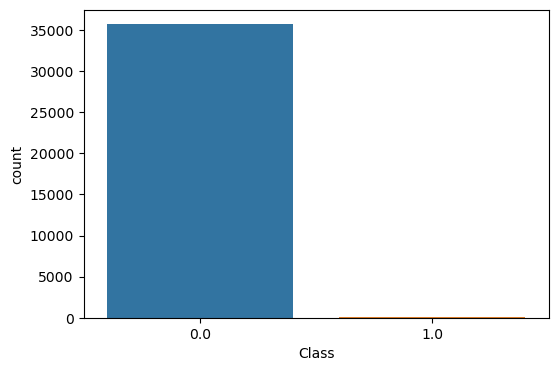

In [8]:
plt.figure(figsize = (6,4))

sns.countplot(
    x = 'Class',
    data = df
)

print("Fraud vs Non-Fraud Transactions")
plt.show()

# Step 7: Percentage Distribution

In [9]:
fraud_percent = round(
    (df['Class'].value_counts()[1] / len(df))*100,2
)

normal_percent = round(
    (df['Class'].value_counts()[0] / len(df))*100,2
)

print("Fraud Transaction :", fraud_percent, '%')

print("Normal Trasaction :", normal_percent, '%')

Fraud Transaction : 0.29 %
Normal Trasaction : 99.71 %


# Step 8: Correlation Heatmap

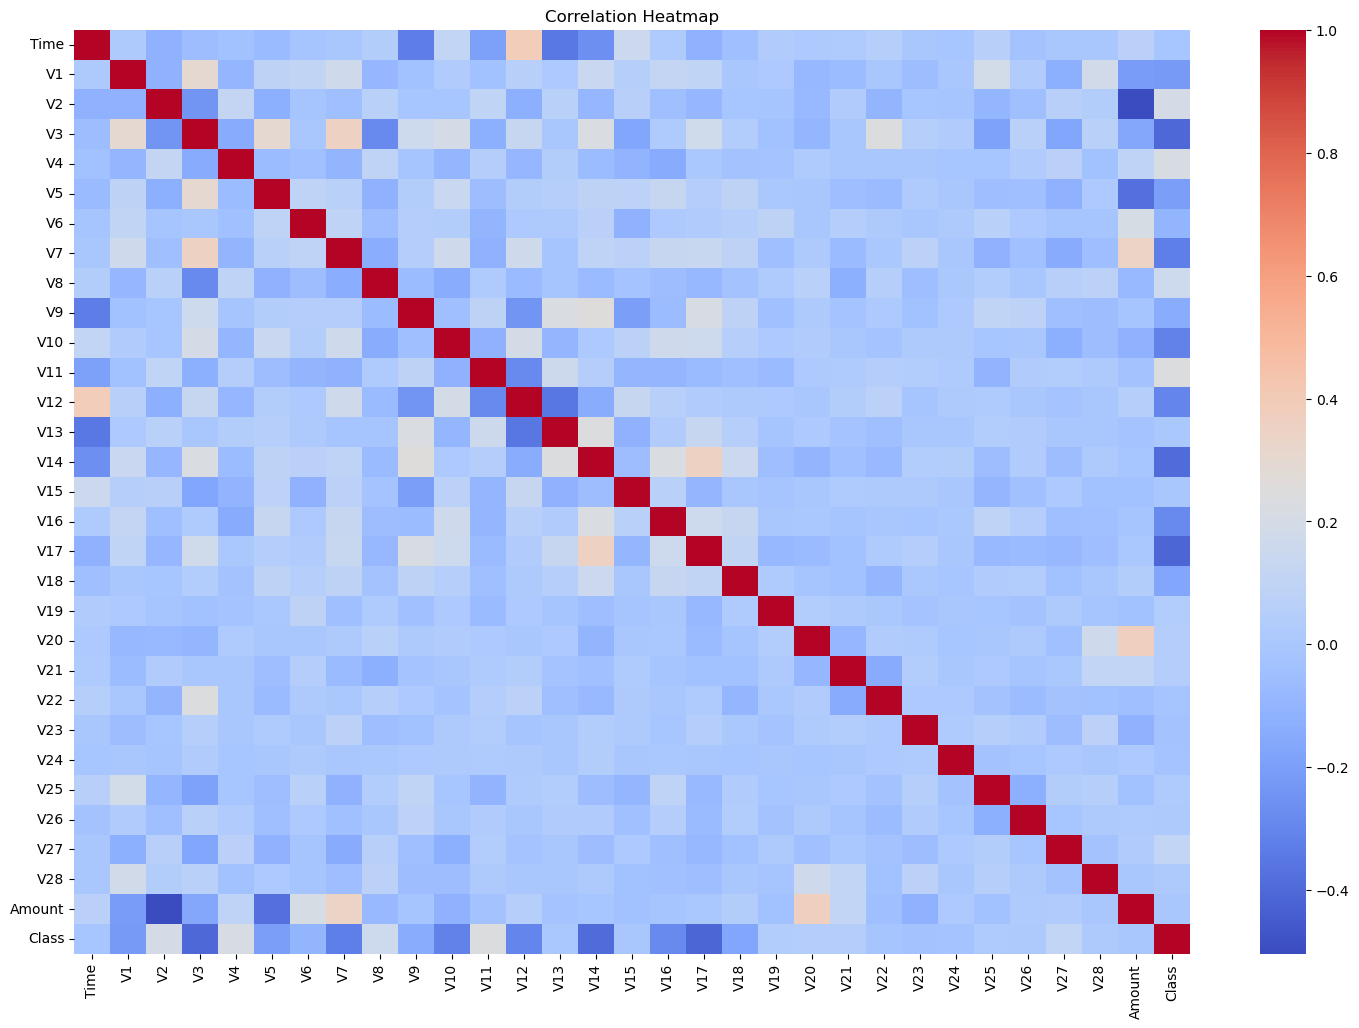

In [10]:
plt.figure(figsize = (18,12))

sns.heatmap(
    df.corr(),
    cmap = 'coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Step 9: Feature and Target Split

In [11]:
X = df.drop('Class', axis = 1)

y = df['Class']

print("X Shape :", X.shape)

print("Y Shape :", y.shape)

X Shape : (35791, 30)
Y Shape : (35791,)


# Step 10: Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print(X_train.shape)
print(X_test.shape)

(28632, 30)
(7159, 30)


# Step 11: Build Random Forest Model

In [13]:
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 2,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

# Step 13: Model Prediction

In [24]:
y_pred = rf_model.predict(X_test)

print(y_pred[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


# Step 14: Accuracy Score

In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", round(accuracy*100,2), '%')

Accuracy : 99.9 %


# Step 15: Classification Report

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7129
         1.0       0.96      0.80      0.87        30

    accuracy                           1.00      7159
   macro avg       0.98      0.90      0.94      7159
weighted avg       1.00      1.00      1.00      7159



# Step 16: Confusion Matrix

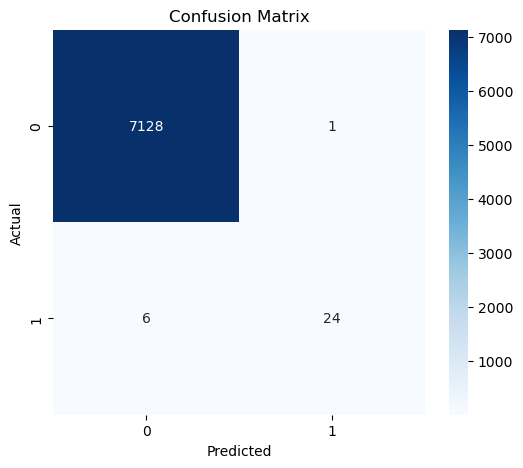

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,5))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 17: Feature Importance

In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by = 'Importance',
    ascending = False
)

importance.head(15)

,Feature,Importance
14,V14,0.163684
3,V3,0.134625
4,V4,0.117340
12,V12,0.116414
10,V10,0.088470
17,V17,0.057543
2,V2,0.056681
11,V11,0.053955
16,V16,0.051663
7,V7,0.023831


# Step 18: Feature Importance Graph

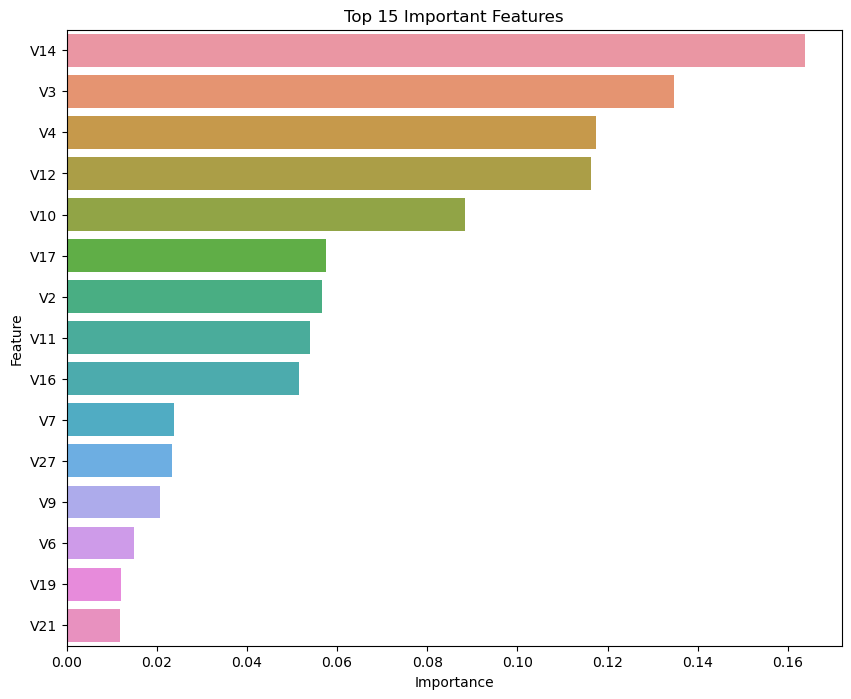

In [19]:
plt.figure(figsize = (10,8))

sns.barplot(
    x = 'Importance',
    y = 'Feature',
    data = importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

# Step 19: ROC Curve

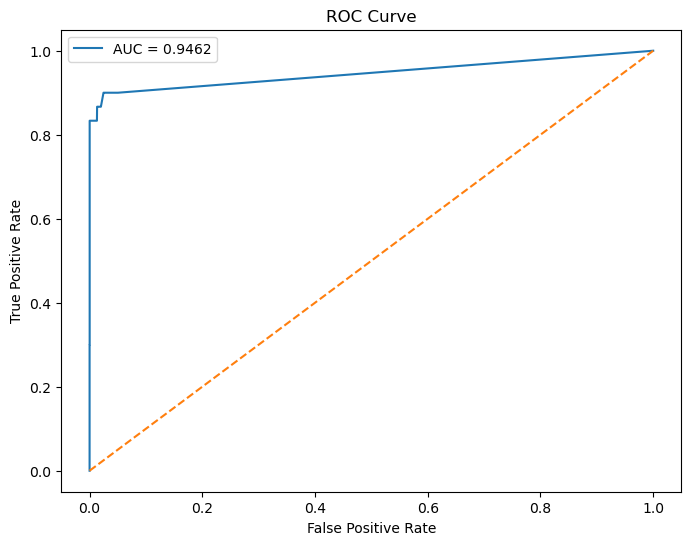

In [20]:
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

# Step 20: Actual vs Predicted

In [21]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
32941,0.0,0.0
17003,0.0,0.0
5360,0.0,0.0
16981,0.0,0.0
22909,0.0,0.0
5535,0.0,0.0
13913,0.0,0.0
30785,0.0,0.0
31975,0.0,0.0
18808,0.0,0.0


# Step 21: Cross Validation Score

In [22]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)

print("CV Scores :", scores)
print("Average CV Score :", scores.mean())

CV Scores : [0.99958095 0.996228   0.99776474 0.99972059 0.99818385]
Average CV Score : 0.9982956250084645


# Step 22: Random Forest Tree Visualization

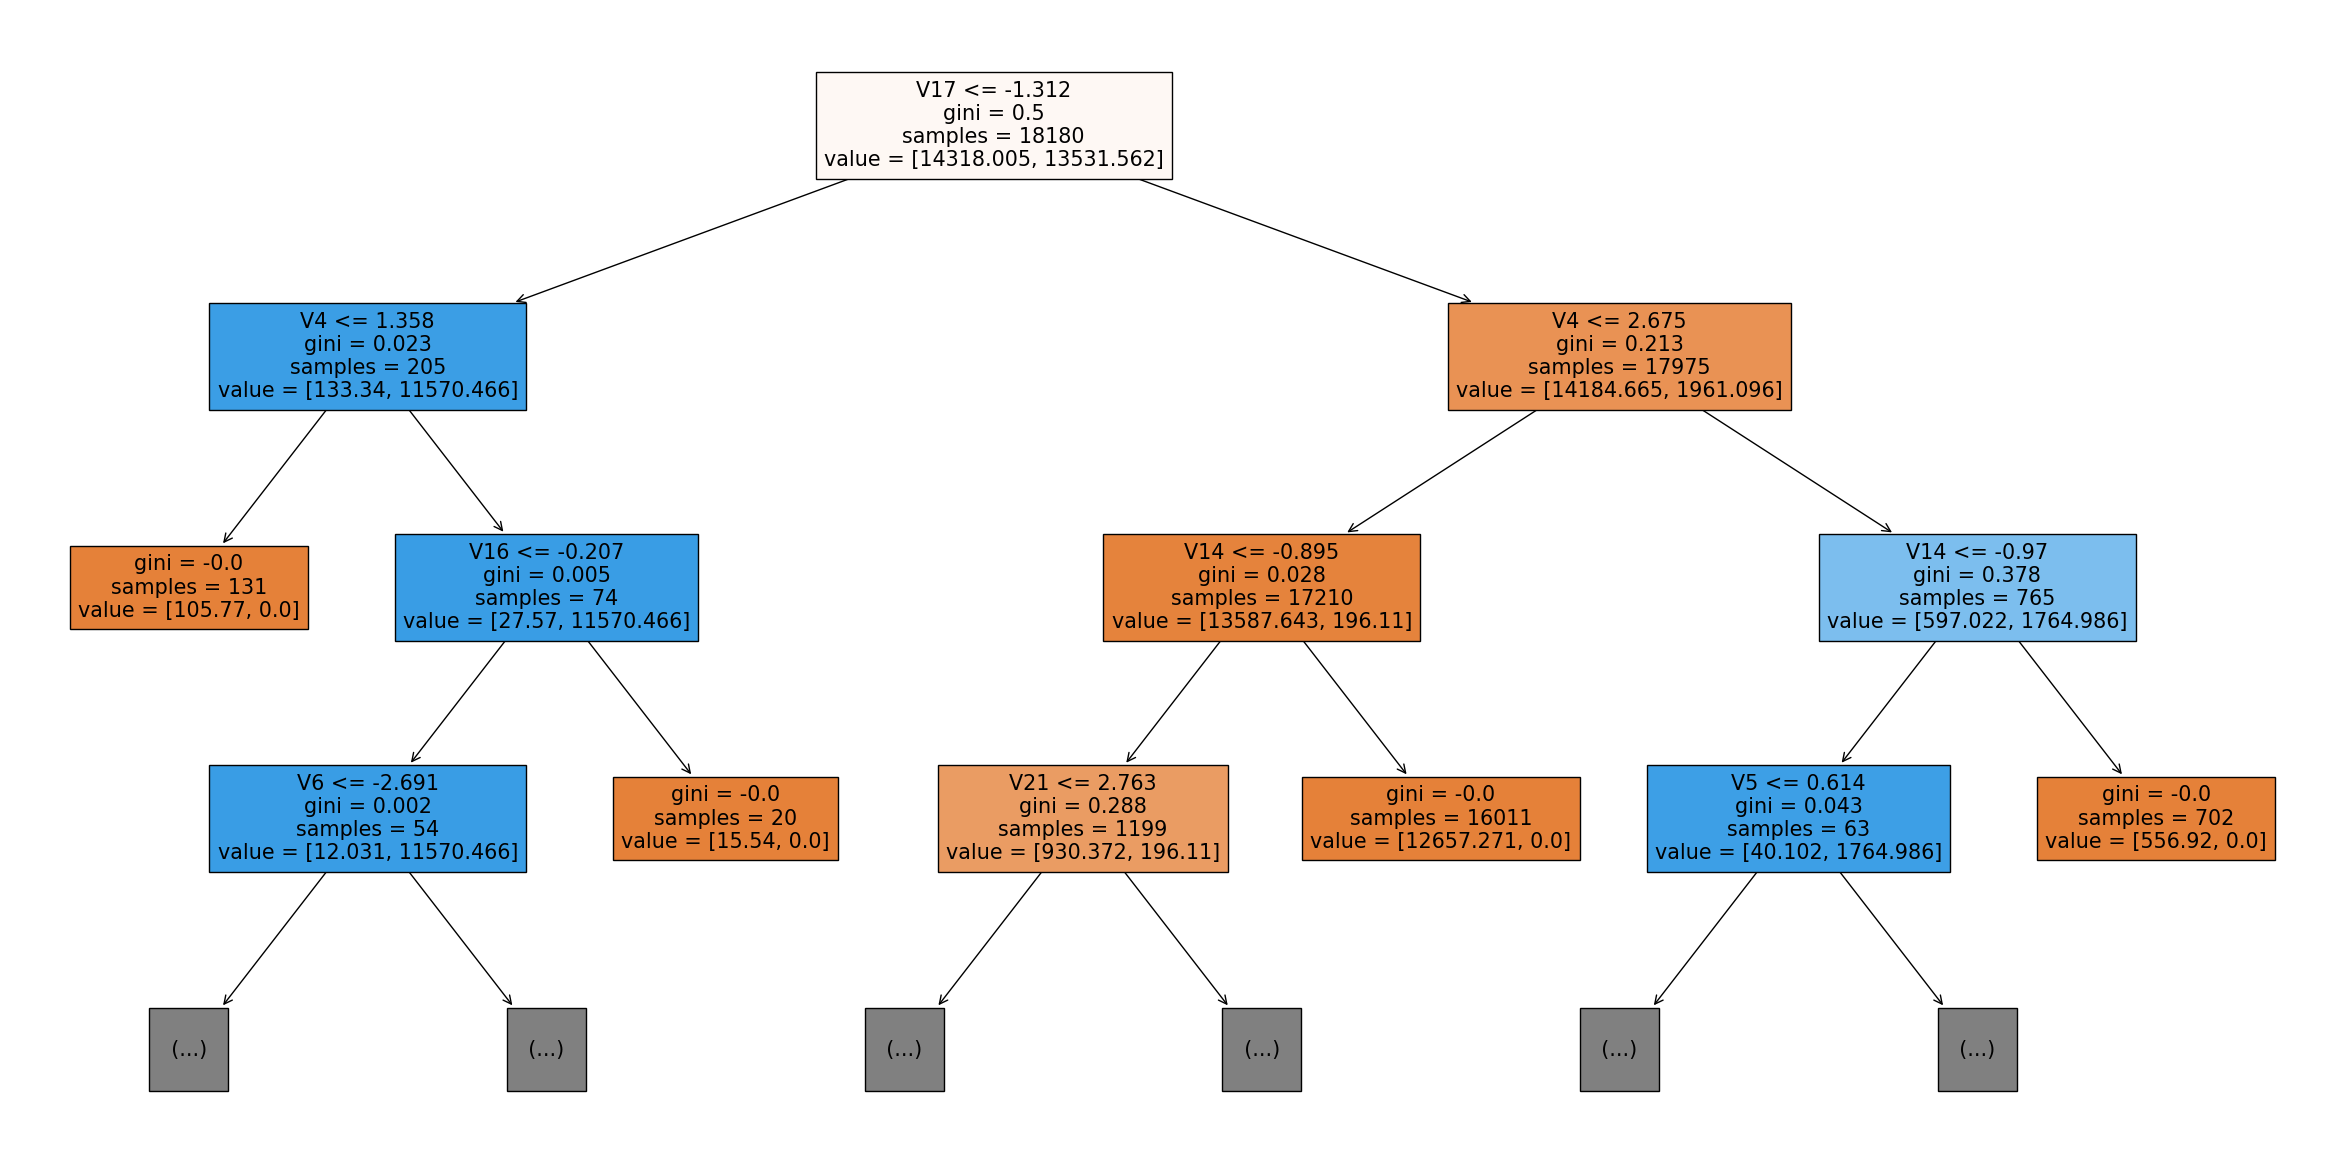

In [23]:
from sklearn.tree import plot_tree

plt.figure(figsize = (30,15))

plot_tree(
    rf_model.estimators_[0],
    max_depth = 3,
    filled = True,
    feature_names = X.columns
)

plt.show()

# Step 23: Fraud Transaction Analysis

In [27]:
fraud = df[df['Class']==1]

print("Fraud Records :", fraud.shape)

fraud.head()

Fraud Records : (103, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1.0
623,472,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1.0
4920,4462,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1.0
6108,6986,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1.0
6329,7519,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1.0


# Step 24: Amount Distribution

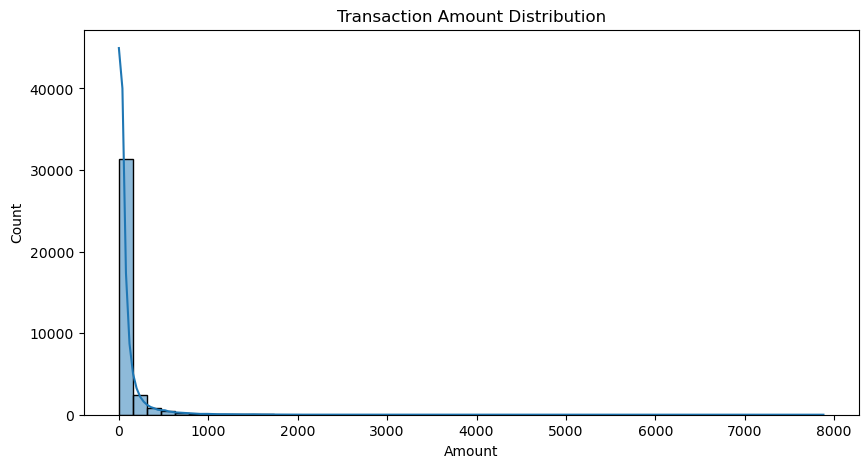

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Amount'],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")

plt.show()

# Step 25: Fraud vs Non-Fraud Amount

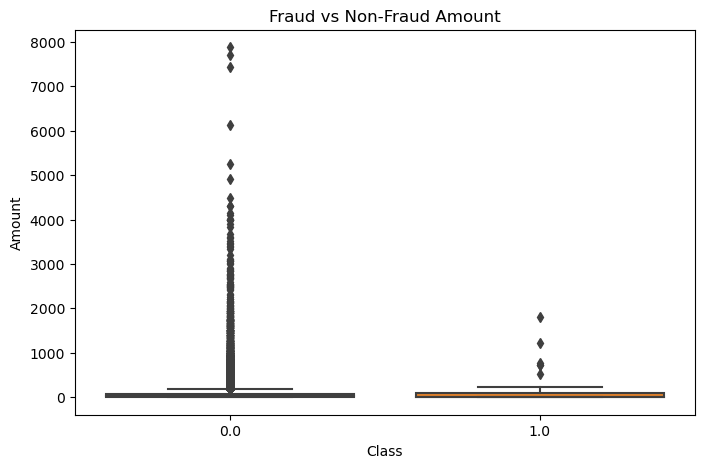

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df
)

plt.title("Fraud vs Non-Fraud Amount")

plt.show()

# Expected Results

| Metric    | Expected Range |
| --------- | -------------- |
| Accuracy  | 99%+           |
| Precision | High           |
| Recall    | High           |
| ROC-AUC   | 0.95+          |
| Algorithm | Random Forest  |
| Target    | Class          |
| Trees     | 300            |


# Random Forest Workflow

# Important Improvement 🚀